# Reverse engineering protected CNC data — a single example

This notebook walks through the **whole pipeline on one machining run**, so you can
see how the library fits together without the batch machinery used to reproduce the
paper (see `scripts/` for that).

We will:

1. **Load** a measurement (positions, velocities, spindle speed).
2. **Protect** it — downsample, add noise, optionally suppress channels.
3. **Reverse** the protection with a Kalman/RTS smoother and reconstruct the tool path.
4. **Segment** the reconstruction into motion states (rapid `G0` / cutting `G1` / standstill).
5. **Disclose** process information — operating-state fractions and feed per tooth.

Each step maps to one module of the `reverse_engineering` package.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from reverse_engineering.classes import (
    AttackConfig,
    CncDataTransformations,
    EvalConfig,
    ProtectionConfig,
)
from reverse_engineering.data_loading import (
    DataAvailabilityScenarios,
    load_csv_measurement_data,
)
from reverse_engineering.protection import apply_protection
from reverse_engineering.reversal import reverse_protection
from reverse_engineering.reconstruction import disclose_feed, disclose_operating_states
from reverse_engineering.velocity_segmentation import create_velocity_segments, plot_segmentation

# Resolve the repository root so this notebook runs from anywhere.
repo_root = Path.cwd()
while not (repo_root / "data").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
DATA_DIR = repo_root / "data"
print("Using data directory:", DATA_DIR)

Using data directory: D:\pd\Projects\reverse-engineering\data


## 1. Load a measurement

We use the contour-milling reference part. The CSV is sampled at 500 Hz (2 ms) and
indexed by elapsed time. The columns are the two axis positions (`*_pos_mm`), the two
axis velocities (`*_vel_mm_per_s`) and the spindle speed (`s_vel_deg_per_s`).

In [2]:
df = load_csv_measurement_data(DATA_DIR / "contour_milling.csv")
print(f"{len(df)} samples, dt = {df.index.diff().median()}")
df.head()

6695 samples, dt = 0 days 00:00:00.002000


,x_pos_mm,y_pos_mm,x_vel_mm_per_s,y_vel_mm_per_s,s_vel_deg_per_s
timestamp_utc,,,,,
0 days 00:00:00,-1.300009,-3.49999,0.0,0.0,38195.999969
0 days 00:00:00.002000,-1.300019,-3.50000,0.0,0.0,38195.999969
0 days 00:00:00.004000,-1.299989,-3.50000,0.0,0.0,38195.999969
0 days 00:00:00.006000,-1.299989,-3.50000,0.0,0.0,38195.999969
0 days 00:00:00.008000,-1.299999,-3.50001,0.0,0.0,38195.999969


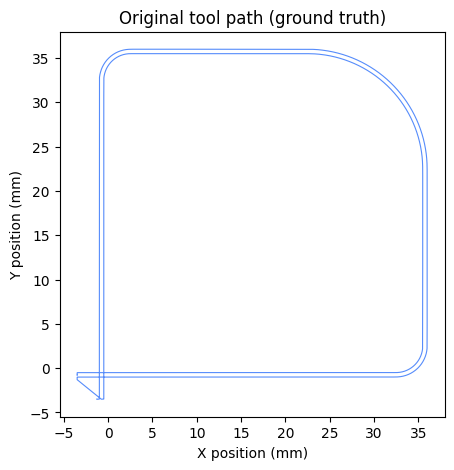

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(df["x_pos_mm"], df["y_pos_mm"], lw=0.8)
ax.set_aspect("equal")
ax.set_xlabel("X position (mm)")
ax.set_ylabel("Y position (mm)")
ax.set_title("Original tool path (ground truth)")
plt.show()

## 2. Protect the data

All intermediate signals live on a single `CncDataTransformations` container, which we
seed with the original measurement. The behaviour is driven by an `EvalConfig`:

* **`ProtectionConfig`** — the data owner's defense. Here we publish *both* positions and
  velocities (`DataAvailabilityScenarios.ALL`), downsample 500 Hz → 10 Hz (`100` ms) and
  add Gaussian noise with std equal to `0.3 ×` each channel's own std.
* **`AttackConfig`** — what the adversary knows/assumes when reversing the protection.

Try changing `noise_standard_deviation_multiplier`, `downsampling_rate_ms` or the
`data_availability_scenario` to see how much harder reconstruction becomes.

In [4]:
data = CncDataTransformations(original=df, dt_original=df.index.diff().median())

cfg = EvalConfig(
    protection=ProtectionConfig(
        data_availability_scenario=DataAvailabilityScenarios.ALL,
        noise_standard_deviation_multiplier=0.3,
        downsampling_rate_ms=100,
        keep_original_index_before_downsampling=False,
        random_state=0,
    ),
    attack=AttackConfig(
        start_pos_known=True,
        end_pos_known=False,
        noise_estimation_window_duration_s=0.1,
    ),
)

data = apply_protection(data, cfg.protection)
print("Original :", data.original.shape)
print("Downsampled:", data.aggregated.shape)
print("Published (noisy):", data.noisy.shape, "->", list(data.noisy.columns))

Original : (6695, 5)
Downsampled: (134, 5)
Published (noisy): (134, 4) -> ['x_pos_mm', 'y_pos_mm', 'x_vel_mm_per_s', 'y_vel_mm_per_s']


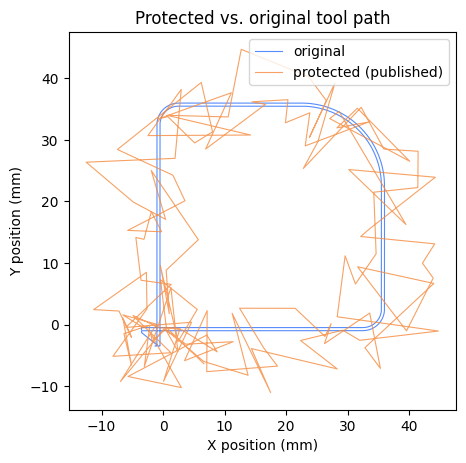

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(data.original["x_pos_mm"], data.original["y_pos_mm"], lw=0.8, label="original")
ax.plot(data.noisy["x_pos_mm"], data.noisy["y_pos_mm"], lw=0.8, alpha=0.8, label="protected (published)")
ax.set_aspect("equal")
ax.set_xlabel("X position (mm)")
ax.set_ylabel("Y position (mm)")
ax.set_title("Protected vs. original tool path")
ax.legend()
plt.show()

## 3. Reverse the protection (the "attack")

`reverse_protection` runs a small hyper-parameter sweep per requested filter and keeps,
for each, the reconstruction with the lowest position+velocity error against the ground
truth. We request the `kalman` smoother plus the `none` baseline (the published signal
with any missing channel reconstructed). Results are stored in `data.reversed`.

In [6]:
data = reverse_protection(data, cfg, methods=["none", "kalman"])
print("Reconstructions available:", list(data.reversed))
print("Best Kalman parameters:", data.filter_params["kalman"])

reconstructed = data.reversed["kalman"]
reconstructed.head()

Reconstructions available: ['none', 'kalman']
Best Kalman parameters: {'q_j': np.float64(10000.0)}


,x_pos_mm,y_pos_mm,x_vel_mm_per_s,y_vel_mm_per_s
timestamp_utc,,,,
0 days 00:00:00,4.516209,-4.926704,-2.494369,3.440494
0 days 00:00:00.100000,4.214657,-4.658161,-3.551542,1.830078
0 days 00:00:00.200000,3.804059,-4.552642,-4.631591,0.495246
0 days 00:00:00.300000,3.309079,-4.496286,-4.989126,0.832237
0 days 00:00:00.400000,2.872643,-4.384354,-3.643021,1.267068


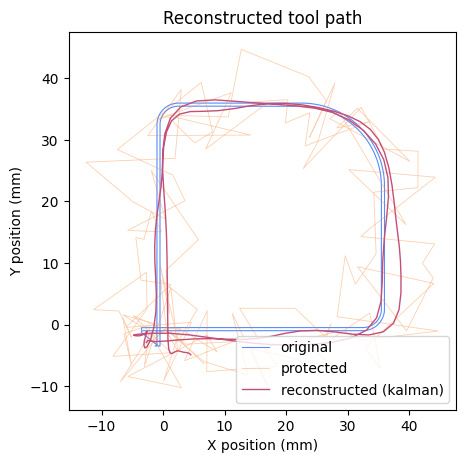

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(data.original["x_pos_mm"], data.original["y_pos_mm"], lw=0.8, label="original")
ax.plot(data.noisy["x_pos_mm"], data.noisy["y_pos_mm"], lw=0.6, alpha=0.4, label="protected")
ax.plot(reconstructed["x_pos_mm"], reconstructed["y_pos_mm"], lw=1.0, label="reconstructed (kalman)")
ax.set_aspect("equal")
ax.set_xlabel("X position (mm)")
ax.set_ylabel("Y position (mm)")
ax.set_title("Reconstructed tool path")
ax.legend()
plt.show()

## 4. Segment the reconstruction into motion states

From the reconstructed velocity magnitude we detect change points and label each
segment as **standstill**, rapid traverse (**`G0`**) or cutting (**`G1`**). The cutting
segments are where the actual machining happens.

Detected 5 segments


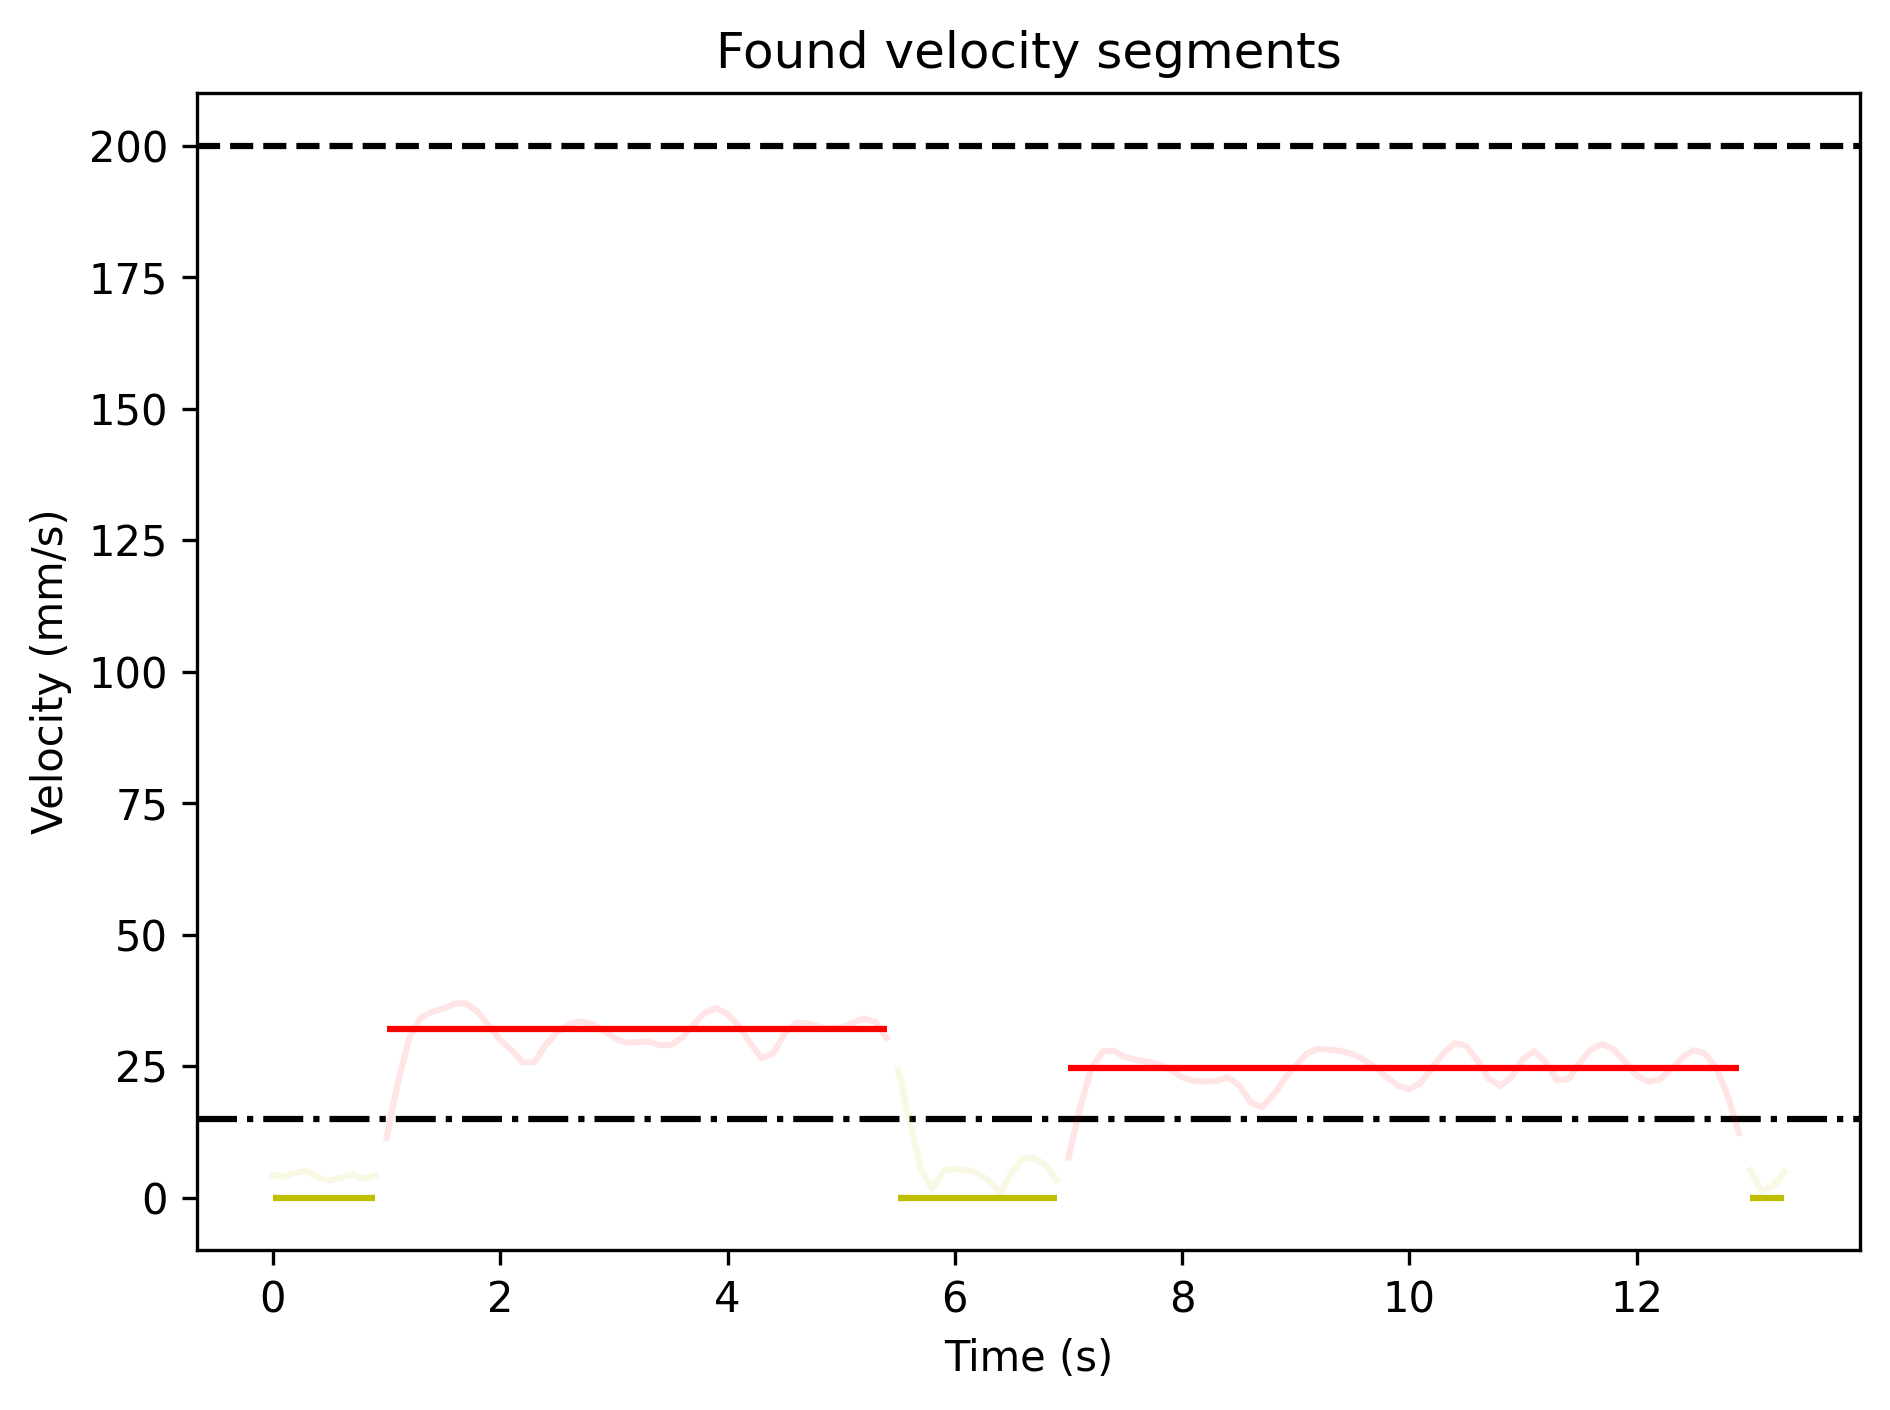

In [8]:
standstill_threshold_mm_per_s = 15
g0_threshold_mm_per_s = 200
min_segment_duration_s = 0.3

velocity_magnitude = np.hypot(reconstructed["x_vel_mm_per_s"], reconstructed["y_vel_mm_per_s"])
min_segment_length = int(max(1, min_segment_duration_s / (cfg.protection.downsampling_rate_ms / 1e3)))
jump = int(max(5, min_segment_length // 2))

data.vel_segments = create_velocity_segments(
    velocity_magnitude,
    standstill_threshold_mm_per_s=standstill_threshold_mm_per_s,
    g0_threshold_mm_per_s=g0_threshold_mm_per_s,
    min_segment_length=min_segment_length,
    jump=jump,
)
print(f"Detected {len(data.vel_segments)} segments")

fig = plot_segmentation(
    velocity_magnitude, data.vel_segments, standstill_threshold_mm_per_s, g0_threshold_mm_per_s
)
plt.show()

## 5. Disclose process information

Finally we extract the manufacturing know-how that protection is meant to hide:

* the **fraction of time** in each operating state, and
* the **feed per tooth** of every cutting segment (needs the spindle speed and the tool's
  tooth count — here 3 teeth).

In [9]:
fraction_standstill, fraction_g1, fraction_g0 = disclose_operating_states(data)
print("Operating-state fractions (reconstructed):")
print(f"  standstill : {fraction_standstill:6.1%}")
print(f"  cutting G1 : {fraction_g1:6.1%}")
print(f"  rapid   G0 : {fraction_g0:6.1%}")

spindle_rpm = data.aggregated["s_vel_deg_per_s"] / 360 * 60
segments = disclose_feed(data.vel_segments, spindle_rpm, n_teeth=3)
feeds = [seg.feed for seg in segments if seg.feed is not None]
print("\nDisclosed feed per tooth (mm) for cutting segments:")
for seg in segments:
    if seg.feed is not None:
        print(f"  segment {seg.segment_index}: f_z = {seg.feed:.4f} mm  (n = {seg.spindle_rpm:.0f} rpm)")

Operating-state fractions (reconstructed):
  standstill :  21.6%
  cutting G1 :  78.4%
  rapid   G0 :   0.0%

Disclosed feed per tooth (mm) for cutting segments:
  segment 1: f_z = 0.1009 mm  (n = 6366 rpm)
  segment 3: f_z = 0.0517 mm  (n = 9549 rpm)


## Where to go next

* Re-run with a stronger protection (`noise_standard_deviation_multiplier=0.8`,
  `downsampling_rate_ms=100`) and watch the reconstruction and disclosed feed degrade.
* Switch `data_availability_scenario` to `POSITION` or `VELOCITY` to publish only one
  channel group — the missing channel is then reconstructed by differentiation/integration.
* Other disclosure functions live in `reverse_engineering.reconstruction`
  (`disclose_radial_engagement`, `disclose_radius`, `disclose_machined_area`).
* To reproduce the full paper evaluation across the whole configuration grid, run the
  numbered `scripts/` in order (see the README).